# This needs to be your file path!!

In [21]:
import sys, os
import pandas as pd
from pathlib import Path
import re

ELI_lamp_path = "/Users/cmcanespie/Documents/Gemini_cells_2024/Gemini_cells_2024/"

# From here, nothing should change

In [22]:
ROOT_FOLDER = os.path.dirname(ELI_lamp_path) # point this to the folder containing LAMP
print(ROOT_FOLDER)
sys.path.append(ROOT_FOLDER)
from LAMP import Experiment
# ----------------------------------
import matplotlib.pyplot as plt 
import numpy as np
from scipy.signal import savgol_filter

ex = Experiment(ROOT_FOLDER)
ESpec = ex.get_diagnostic('ESpec')
ESpec_low = ex.get_diagnostic('ESpec_low')

/Users/cmcanespie/Documents/Gemini_cells_2024/Gemini_cells_2024
Using DAQ: GeminiMirage
Adding Diagnostic: ESpec [ESpec]
Adding Diagnostic: ESpec_low [ESpec]


In [23]:
if ex.DAQ.config is None:
    ex.DAQ.config = {}
ex.DAQ.config.setdefault("shotnum_zfill", 0)
print("DAQ config (patched):", ex.DAQ.config)

DAQ config (patched): {'shotnum_zfill': 0}


In [24]:
# /Users/cmcanespie/Documents/Gemini_cells_2024/Mirage/HighEspec/20240306/run05
timeline = {'date': 20240304, 'run': 'run11'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec', timeline)
shot_dicts

[{'date': 20240304, 'run': 'run11', 'shotnum': 1},
 {'date': 20240304, 'run': 'run11', 'shotnum': 2},
 {'date': 20240304, 'run': 'run11', 'shotnum': 3},
 {'date': 20240304, 'run': 'run11', 'shotnum': 4},
 {'date': 20240304, 'run': 'run11', 'shotnum': 5},
 {'date': 20240304, 'run': 'run11', 'shotnum': 6},
 {'date': 20240304, 'run': 'run11', 'shotnum': 7},
 {'date': 20240304, 'run': 'run11', 'shotnum': 8},
 {'date': 20240304, 'run': 'run11', 'shotnum': 9},
 {'date': 20240304, 'run': 'run11', 'shotnum': 10},
 {'date': 20240304, 'run': 'run11', 'shotnum': 11},
 {'date': 20240304, 'run': 'run11', 'shotnum': 12},
 {'date': 20240304, 'run': 'run11', 'shotnum': 13},
 {'date': 20240304, 'run': 'run11', 'shotnum': 14}]

# Plot an individual shot

for checking things

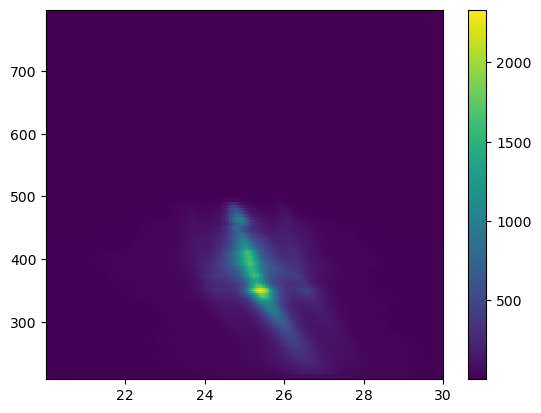

In [25]:
timeline = {'date': 20240304, 'run': 'run11'}
eg_shot = {'date': 20240304, 'run': 'run11', 'shotnum': 1}
img, x, y = ESpec.get_proc_shot(eg_shot, debug=False, roi_MeV=[200,800], roi_mrad=[20,30])

plt.pcolormesh(x, y, img)
plt.colorbar()

# Plot overplotted spectra

For when nothing is changed in a run

[{'date': 20240304, 'run': 'run11', 'shotnum': 1}, {'date': 20240304, 'run': 'run11', 'shotnum': 2}, {'date': 20240304, 'run': 'run11', 'shotnum': 3}, {'date': 20240304, 'run': 'run11', 'shotnum': 4}, {'date': 20240304, 'run': 'run11', 'shotnum': 5}, {'date': 20240304, 'run': 'run11', 'shotnum': 6}, {'date': 20240304, 'run': 'run11', 'shotnum': 7}, {'date': 20240304, 'run': 'run11', 'shotnum': 8}, {'date': 20240304, 'run': 'run11', 'shotnum': 9}, {'date': 20240304, 'run': 'run11', 'shotnum': 10}, {'date': 20240304, 'run': 'run11', 'shotnum': 11}, {'date': 20240304, 'run': 'run11', 'shotnum': 12}, {'date': 20240304, 'run': 'run11', 'shotnum': 13}, {'date': 20240304, 'run': 'run11', 'shotnum': 14}]


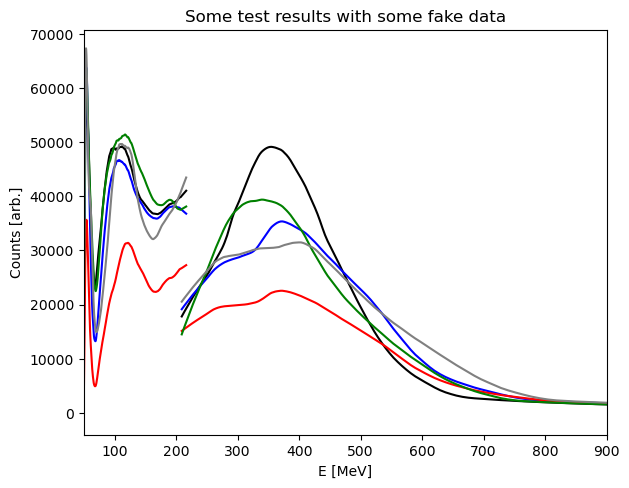

In [26]:
timeline = {'date': 20240304, 'run': 'run11'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec', timeline)

charge = []
ave_spec = []

print(shot_dicts)

colors= ['k', 'b', 'r', 'g', 'grey']

for n,i in enumerate(shot_dicts[0:5]):
    img, y, MeV = ESpec.get_proc_shot(i, debug=False, apply_charge=True) #With apply charge = True, the charge is taken from the calib.toml file
    img = np.rot90(img)
    img[img<=0] = 0

    spec = abs(np.sum(img, axis=0)) 
    spec = savgol_filter(spec, window_length=51, polyorder=1)
    plt.plot(MeV, spec, color=colors[n], label='Shot '+str(n+1))

    img_low, MeV_low, y_low = ESpec_low.get_proc_shot(i, debug=False, apply_charge=True)
    img_low[img_low<=0] = 0

    spec = abs(np.sum(img_low, axis=0))
    spec = savgol_filter(spec, window_length=51, polyorder=1)
    plt.plot(MeV_low, spec, color=colors[n], label='Shot '+str(n+1))

# plt.legend()
plt.xlabel('E [MeV]')
plt.ylabel('Counts [arb.]')
# plt.ylim(0, )
plt.xlim(np.min(MeV_low), 900)
plt.tight_layout()
plt.title('Some test results with some fake data')
plt.show()
